In [1]:
import sys, os
current_dir = os.getcwd()
project_root = current_dir[:current_dir.find("src") - 1]
sys.path.insert(0, project_root)
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression
from src.models.train_model.train_model import *

logger = CustomLogger(__name__).get_logger()


In [3]:
def select_data(goodness):
    csv_semi_processed_path = os.path.join(project_root, "data", "processed", "semi_processed.csv")
    df = pd.read_csv(csv_semi_processed_path, encoding='utf-8')

    df_r_selected = Data_selector(df).select_peaks(goodness)
    logger.info(f"Rows with goodness={goodness} have been selected")
    return df_r_selected


def select_features(df_r_selected):
    base_features = ["name", "code", "temperature", "humidity", "dew", "surface_pressure", "temp_sens"]
    time_features = ["hour", "day_of_week", "month"]  # TODO: I have removed "season"
    feature_selector = Feature_selector(df_r_selected, "generation")
    feature_selector.filter_features(features_to_select=base_features + time_features)
    df_f_selected = feature_selector.df
    logger.info(f"Features have been selected successfully")
    return df_f_selected


def train_and_test_model(X, y, folder_path,name,code):
    X_train, X_test, y_train, y_test = split_X_and_y(X, y, test_size=0.2, shuffle=False)

    # model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, max_depth=3, learning_rate=0.1)
    model = LinearRegression()
    model.fit(X_train, y_train)
    dump(model, f"{folder_path}/model_{name}_{code}.joblib")

    y_pred_train = model.predict(X_train)
    rmse_error_train = compute_relative_rmse(y_pred_train, y_train)

    y_pred_test = model.predict(X_test)
    rmse_error_test = compute_relative_rmse(y_pred_test, y_test)
    return rmse_error_train, rmse_error_test


if __name__ == "__main__":
    goodness_to_select = 5
    save_model_folder = os.path.join(project_root, "src", "models", "fitted_models")

    df_r_selected = select_data(goodness_to_select)

    df_f_selected = select_features(df_r_selected)

    ds_n_c = Data_selector(df_f_selected)
    ds_n_c.df = ds_n_c.df.dropna()
    power_plants = ds_n_c.df[['name', 'code']].drop_duplicates()
    train_errors = []
    test_errors = []
    num = []
    for row in power_plants.itertuples():
        name, code = row.name, row.code
        logger.info(f"Train and test data related to {name}_{code}:")

        df_n_c = ds_n_c.filter_name_code(name, code)

        fs_n_c = Feature_selector(df_n_c, "generation")
        fs_n_c.filter_features(features_to_drop=["name", "code"])
        X, y = fs_n_c.get_X_and_y()
        # X = make_onehot(X)

        train_error, test_error = train_and_test_model(X, y, save_model_folder,name,code)
        logger.info(f"Train rmse error: {train_error:.3f}%, Test rmse error: {test_error:.3f}% , Number of data: {len(y)}")
        train_errors.append(train_error)
        test_errors.append(test_error)
        num.append(len(y))
    
    num = np.array(num)
    train_errors = np.array(train_errors)
    test_errors = np.array(test_errors)

2025-10-20 10:38:55 - __main__ - INFO - Rows with goodness=5 have been selected
2025-10-20 10:38:55 - __main__ - INFO - Features have been selected successfully
2025-10-20 10:38:55 - __main__ - INFO - Train and test data related to جنوب اصفهان - چهلستون_G11:
2025-10-20 10:38:55 - __main__ - INFO - Train rmse error: 1.356%, Test rmse error: 3.693% , Number of data: 861
2025-10-20 10:38:55 - __main__ - INFO - Train and test data related to جنوب اصفهان - چهلستون_G12:
2025-10-20 10:38:55 - __main__ - INFO - Train rmse error: 0.000%, Test rmse error: 396.467% , Number of data: 9
2025-10-20 10:38:55 - __main__ - INFO - Train and test data related to جنوب اصفهان - چهلستون_G13:
2025-10-20 10:38:55 - __main__ - INFO - Train rmse error: 0.000%, Test rmse error: 22.976% , Number of data: 6
2025-10-20 10:38:55 - __main__ - INFO - Train and test data related to جنوب اصفهان - چهلستون_G15:
2025-10-20 10:38:55 - __main__ - INFO - Train rmse error: 0.000%, Test rmse error: 1.033% , Number of data: 7
20

In [66]:
num[np.where(test_errors>2.5)[0]]

array([861,   9,   6,   4, 223, 143, 177])

In [67]:
np.where(test_errors>2.5)[0]

array([ 0,  1,  2,  4, 18, 19, 20], dtype=int64)

In [40]:
test_errors

array([  3.69330064, 396.46682444,  22.97649722,   1.03336685,
        12.69515284,   1.60473981,   1.76326754,   2.07113756,
         1.76970252,   0.95163078,   1.66919777,   1.26825424,
         1.07707304,   1.50361861,   1.77098973,   0.78528205,
         0.90227466,   1.60378134,   3.24966056,   5.89846281,
         2.54802205,   1.62064707,   1.06646115,   1.24445725,
         1.46977392,   1.63485142,   1.40388417,   1.38565472,
         1.38009058,   2.47125148,   2.11307727,   0.96535163,
         1.10907393,   2.03325967,   0.44142002,   0.85390044,
         1.33160601,   0.75188037,   1.17609299,   1.31941664,
         0.74738175,   0.79378461,   1.37700373,   1.43625683,
         0.80477982])

In [41]:
index = list(range(len(num)))
index.pop(4)
index.pop(3)
index.pop(2)
index.pop(1)

1

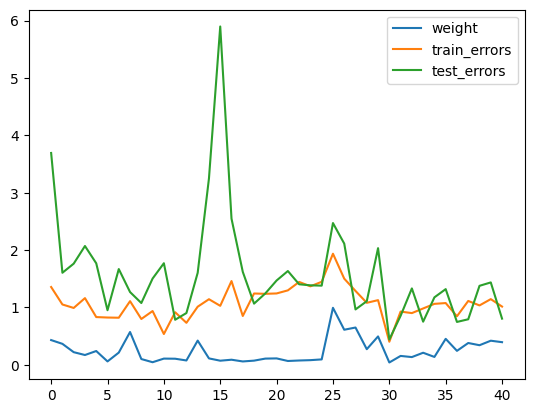

In [42]:
plt.plot(num[index]/sum(num[index])*10,label = "weight")
plt.plot(train_errors[index],label = "train_errors")
plt.plot(test_errors[index],label = "test_errors")
plt.legend()


(array([10., 15., 10.,  3.,  0.,  2.,  0.,  0.,  0.,  1.]),
 array([0.44142002, 0.9871243 , 1.53282858, 2.07853286, 2.62423714,
        3.16994142, 3.7156457 , 4.26134997, 4.80705425, 5.35275853,
        5.89846281]),
 <BarContainer object of 10 artists>)

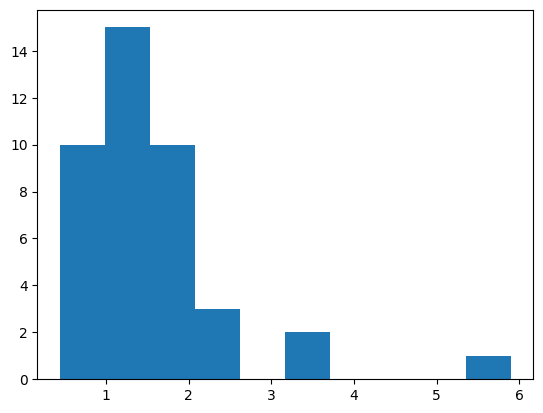

In [43]:
plt.hist(test_errors[index])

In [49]:
np.average(test_errors[index],weights=num[index])

1.6420004193852102

(array([4., 0., 0., 1., 1., 2., 1., 5., 1., 2., 3., 2., 0., 2., 0., 1., 0.,
        1., 0., 0., 1., 1., 1., 0., 2., 0., 0., 1., 0., 0., 0., 0., 0., 0.,
        1., 0., 1., 0., 1., 1., 0., 0., 2., 1., 0., 1., 0., 0., 0., 1., 0.,
        0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 1., 0., 0., 0., 1., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]),
 array([   4.  ,   23.81,   43.62,   63.43,   83.24,  103.05,  122.86,
         142.67,  162.48,  182.29,  202.1 ,  221.91,  241.72,  261.53,
         281.34,  301.15,  320.96,  340.77,  360.58,  380.39,  400.2 ,
         420.01,  439.82,  459.63,  479.44,  499.25,  519.06,  538.87,
         558.68,  578.49,  598.3 ,  618.11,  637.92,  657.73,  677.54,
         697.35,  717.16,  736.97,  756.78,  776.59,  796.4 ,  816.21,
         836.02,  855.83,  875.64,  895.45,  915.26,  935.07,  954.88,
         974.69,  994.5 , 1014.31, 1034.12, 1053.93, 

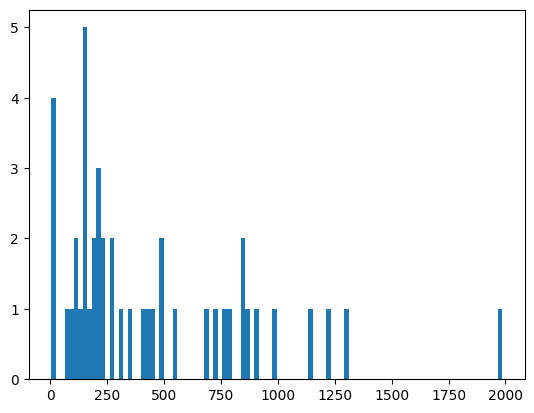

In [55]:
plt.hist(num,bins=100)